# Assignment 2: Scalability of Support Vector Machines
## Miles Nordwall, Nathan Nail

In [3]:
import numpy as np
from datetime import datetime

In [4]:
NUM_ITER = 10000
ETA = 0.01

#global variable to keep track of runtimes of each model
SVC_IRIS_t = 0.0

### Task #1 Implement LinearSVC
algo seems to work
- [ ] test on make_classification

In [6]:
class LinearSVC(object):
    """
    Linear Support Vector Classifier
    Params: 
    eta (float) : Learning rate (between 0.0 and 1.0)
    n_iter (int) : Number of passes over the training dataset.
    random_state (int) : Random number generator seed for random weight initialization.

    Attrs:
    w_ (1d-array) : Weights after fitting with bias absorbed at X[0].
    losses_ (list) : Hinge Loss with L2-regularization loss function values in each epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.rand_gen = []
        self.w_initialized = False

    def fit(self, X, y, C=0.1):
        """
        Learns parameters from the training data
        Params:
        X {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples and n_features is the number of features.
        y (array-like) ,shape = [n_examples]
        Target values.
        C {float} = regularization hyperparameter 

        Returns:
        self : Instance of LinearSVC
        """
        self.losses_ = []
        X = self._initialize_weights(X,X.shape[1])
        c_n = C /X.shape[0]
        
        for _ in range(self.n_iter):
            
            X, y = self._shuffle(X, y)
            
            for xi, yi in zip(X, y):
                
                y_hat = self.net_input(xi)
                fn_margin = 1 - (yi*y_hat)
                Li = np.maximum(0,fn_margin)

                #gd = self.w_ + c_n * (-yi*xi) #dL/dw
                b_update = 0
                if fn_margin > 0:
                    gd = self.w_ + c_n * (-yi*xi) #dL/dw
                    b_update = -yi
                else:
                    gd = self.w_
                    
                
                self.w_ += self.eta* (-gd)
                self.b_ += self.eta* b_update
        return self
        

    
    def _initialize_weights(self, X, m):
        """Initialize weights to small random numbers
        """
        self.b_ = np.float_(0.)
        self.rand_gen = np.random.RandomState(self.random_state)
        self.w_ = self.rand_gen.normal(loc=0.0, scale=0.01,
                                  size=m)
        self.w_initialized = True
        return X
        

    def _update_weights(self, xi, y):
        """Calculate hinge loss then apply GD to L wrt w_"""
        y_hat = self.net_input(xi)
        Li = np.max(0, 1 - (y*y_hat))
        loss = c_n * (Li + (0.5 * (self.w_.shape[0])^2))
        self.w_ += self.w_ + self.eta - loss
        self.b_ += gd
        return loss
        
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rand_gen.permutation(len(y))
        return X[r], y[r]

    def net_input(self, X): #TODO1 the net_input for svc is w^Tx-b right? unabsorb b?
        """Calculate net input"""
        return np.dot(X, self.w_) - self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.sign(self.net_input(X))
    
        

### Task #2 make_classification function
$$\bar{a}^T \bar{x} = b$$
$$\{ \bar{x} \in \mathbb{R}^d | \bar{a}^T \bar{x} = b\}$$
$$\text{where } b=0$$

In [8]:
def make_classification(d,n, u=100,seed=1):
    """
    Generates a set of linearly seperable data
    based on a random seperation hyperplane
    d (int) : dimension of set of points
    """
    rand_gen = np.random.RandomState(seed)
    #generate random vector a s.t ||a||=d
    a = rand_gen.random(size=d) #TODO values are between [0-1] btw, is that okay?
    
    #randomly select n samples in range of [-u,u] in each dimension using a gaussian
    x = []
    for i in range(n):
        x_gauss = rand_gen.normal(scale=u,size=d)
        x.append(x_gauss)
    X = np.array(x)
    #give each xi a label yi 
    y = []
    for j in range(n):
        if a.T.dot(X[j]) < 0: #is this correct?
            yi = -1
        else:
            yi = 1
        y.append(yi)
    Y = np.array(y)

    #TODO make the first 70% training, and the last 30% test

    print(a)
    print(X)
    print(a.T.dot(X))
    print(Y)
    

make_classification(d=3,n=3,seed=1)

[4.17022005e-01 7.20324493e-01 1.14374817e-04]
[[ -80.21728386  -44.88778077 -110.5935076 ]
 [-165.45154524 -236.34686048  113.53453479]
 [-101.70141365   63.73618141  -85.99066067]]
[-152.64280512 -188.95833506   35.65194485]
[-1 -1  1]


In [9]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None,
                          resolution=0.02):
    #taken from textbook
    # setup marker generator and color map
    markers = ('o', 'x', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o',
                    s=100, label='Test set')

In [58]:
import os
import pandas as pd
s = os.path.join('https://archive.ics.uci.edu', 'ml',
                 'machine-learning-databases',
                 'iris','iris.data')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

X_4 = df.iloc[50:150, [0, 2]].to_numpy()
Y_ref = df.iloc[50:150, 4].to_numpy()

#Y_ref = np.where(Y_ref == 'Iris-setosa',-1,Y_ref)
Y_ref = np.where(Y_ref == 'Iris-versicolor',1,Y_ref)
Y_ref = np.where(Y_ref == 'Iris-virginica',-1,Y_ref)

X_std4 = np.copy(X_4)
X_std4[:,0] = (X_4[:,0] - X_4[:,0].mean()) / X_4[:,0].std()
X_std4[:,1] = (X_4[:,1] - X_4[:,1].mean()) / X_4[:,1].std()

/var/folders/q8/dkdmw0695vz4xd77f20xf2h00000gp/T/ipykernel_38846/127553513.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


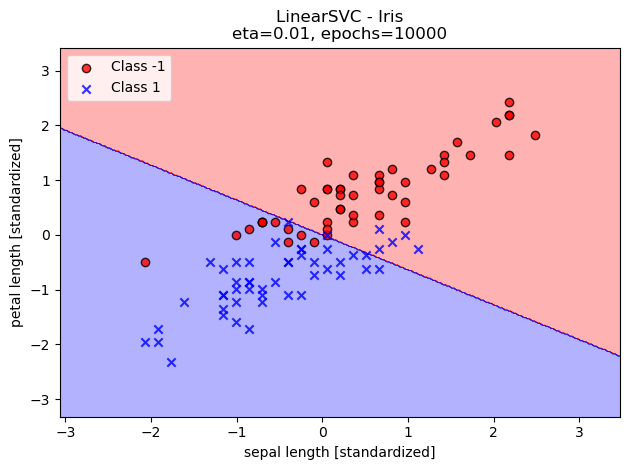

In [59]:
#plotting the decision boundary found for linear svc on the Iris dataset
svc = LinearSVC(n_iter=NUM_ITER, eta=ETA)

svc_iris_start = datetime.now()
svc.fit(X_std4, Y_ref)
svc_iris_end = datetime.now()
SVC_IRIS_t = (svc_iris_end - svc_iris_start).total_seconds() *1000

plot_decision_regions(X_std4, Y_ref, classifier=svc)
plt.title(f'LinearSVC - Iris\n'
          f'eta={ETA}, epochs={NUM_ITER}')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()